# Laboratorio 13 — Regresión lineal simple con Python

## Analítica de Datos

**Docente:** Luis Miguel Gómez Meneses  
**Universidad Cooperativa de Colombia**  
**Programa:** Ingeniería de Software  

---

## 1. Situación de análisis

Una empresa registró la inversión realizada en publicidad en televisión,
radio y prensa en diferentes mercados. También registró las ventas obtenidas
en cada uno de ellos.

En este laboratorio utilizaremos el conjunto de datos **Advertising**,
el cual contiene 200 observaciones y las siguientes variables:

| Variable | Descripción |
|---|---|
| `TV` | Inversión en publicidad en televisión |
| `radio` | Inversión en publicidad en radio |
| `newspaper` | Inversión en publicidad en prensa |
| `sales` | Ventas obtenidas |

Las inversiones publicitarias están expresadas en miles de dólares y las
ventas en miles de unidades.



## Objetivo

Construir un modelo de regresión lineal simple que permita estimar las
ventas de la empresa a partir de su inversión en publicidad en televisión.

En este primer modelo utilizaremos:

$$
X=\text{TV}
$$

como variable predictora, y:
$$
Y=\text{sales}
$$

como variable respuesta.

El modelo que construiremos tendrá la forma:
$$
\widehat{\text{sales}}
=
\beta_0+\beta_1(\text{TV})
$$



## Pregunta principal

**¿Podemos utilizar la inversión en publicidad en televisión para estimar
las ventas de la empresa?**

Para responder esta pregunta exploraremos los datos, construiremos un
diagrama de dispersión, ajustaremos un modelo de regresión y evaluaremos
sus predicciones.

## 2. Importación de librerías

Antes de comenzar el análisis, importaremos las librerías necesarias para:

- cargar y organizar el conjunto de datos;
- realizar cálculos numéricos;
- construir gráficos;
- dividir los datos en entrenamiento y prueba;
- ajustar el modelo de regresión lineal;
- evaluar las predicciones.

Las principales librerías serán:

- **pandas:** manejo de tablas y conjuntos de datos;
- **numpy:** operaciones numéricas;
- **matplotlib y seaborn:** construcción de gráficos;
- **scikit-learn:** construcción y evaluación del modelo.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from scipy.stats import pearsonr
sns.set_theme(style="whitegrid")

## 2. Carga del conjunto de datos

El conjunto de datos se encuentra disponible en el sitio oficial del libro
*An Introduction to Statistical Learning*.

Utilizaremos `pandas` para leer el archivo directamente desde su dirección
web y almacenarlo en un objeto llamado `datos`.

La instrucción `index_col=0` indica que la primera columna del archivo
corresponde al número de cada observación y no a una variable de análisis.

In [2]:
ruta = "/content/Advertising.csv"
datos = pd.read_csv(ruta, index_col=0)
datos.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 3. Inspección inicial del conjunto de datos

Antes de construir el modelo debemos conocer la estructura del conjunto
de datos.

En esta sección verificaremos:

- el número de filas y columnas;
- los nombres de las variables;
- el tipo de dato de cada columna;
- la presencia de valores faltantes;
- la presencia de filas duplicadas.

Esta revisión permite detectar problemas que podrían afectar el análisis.

In [3]:
print("Dimensiones del conjunto de datos:")
print(datos.shape)
print("\nColumnas:")
print(datos.columns.tolist())
print("\nInformación general:")
datos.info()
print("\nValores faltantes por columna:")
print(datos.isnull().sum())
print("\nCantidad de filas duplicadas:")
print(datos.duplicated().sum())

Dimensiones del conjunto de datos:
(200, 4)

Columnas:
['TV', 'radio', 'newspaper', 'sales']

Información general:
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB

Valores faltantes por columna:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64

Cantidad de filas duplicadas:
0


## Preguntas sobre la estructura de los datos


¿Cuántas observaciones y cuántas variables contiene el conjunto de datos?


¿Cuáles son las variables disponibles en el conjunto de datos?


¿Qué tipo de dato tienen las variables `TV`, `radio`, `newspaper`
y `sales`?


¿El conjunto de datos contiene valores faltantes? Justifique su respuesta
con los resultados obtenidos.


¿El conjunto de datos contiene filas duplicadas?


¿Es necesario eliminar observaciones o imputar datos antes de construir
el modelo de regresión? Explique su respuesta.


## 5. Resumen estadístico de las variables

Después de verificar la estructura del conjunto de datos, calcularemos
las principales medidas estadísticas de cada variable.

La función `describe()` permite obtener:

- cantidad de observaciones;
- media;
- desviación estándar;
- valor mínimo;
- primer cuartil;
- mediana;
- tercer cuartil;
- valor máximo.

Estas medidas permiten conocer la distribución general de las inversiones
publicitarias y de las ventas.

## 4. Resumen estadístico de las variables

Después de verificar la estructura del conjunto de datos, calcularemos
las principales medidas estadísticas de cada variable.

La función `describe()` permite obtener:

- cantidad de observaciones;
- media;
- desviación estándar;
- valor mínimo;
- primer cuartil;
- mediana;
- tercer cuartil;
- valor máximo.

Estas medidas permiten conocer la distribución general de las inversiones
publicitarias y de las ventas.

In [4]:
# Resumen estadístico de las variables
resumen = datos.describe().round(2)

resumen

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


## Preguntas de análisis

**¿Cuál es el promedio de la inversión en televisión y cuál es el promedio
de las ventas?**

**Respuesta:**

Escriba aquí su respuesta.


**¿Entre qué valores se encuentran la inversión en televisión y las
ventas?**

**Respuesta:**

Escriba aquí su respuesta.

**¿El resumen estadístico permite determinar por sí solo si la inversión
en televisión está relacionada con las ventas? Explique.**

**Respuesta:**

Escriba aquí su respuesta.

## 5. Relación entre inversión en televisión y ventas

Antes de construir el modelo de regresión lineal, observaremos gráficamente
la relación entre la inversión en publicidad en televisión y las ventas.

En el diagrama de dispersión:

- el eje horizontal representa la inversión en televisión (`TV`);
- el eje vertical representa las ventas (`sales`);
- cada punto representa una observación del conjunto de datos.

La gráfica permitirá identificar si la relación parece positiva, negativa
o inexistente, y si una recta puede representar razonablemente la tendencia
de los datos.

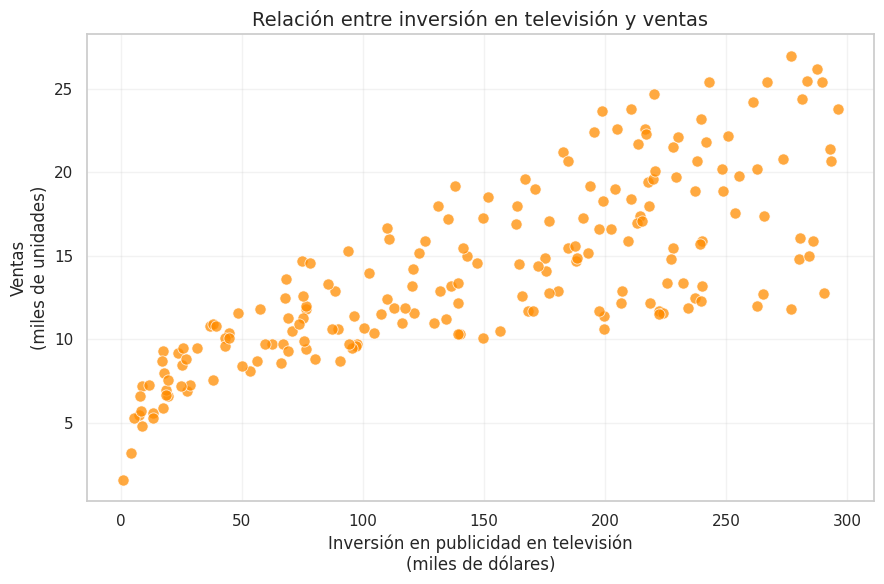

In [5]:
# Diagrama de dispersión entre inversión en TV y ventas
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=datos,
    x="TV",
    y="sales",
    color="darkorange",
    s=65,
    alpha=0.75
)
plt.title(
    "Relación entre inversión en televisión y ventas",
    fontsize=14
)
plt.xlabel(
    "Inversión en publicidad en televisión\n(miles de dólares)"
)
plt.ylabel(
    "Ventas\n(miles de unidades)"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Correlación entre inversión en televisión y ventas

Antes de construir el modelo de regresión lineal, calcularemos la
correlación de Pearson entre la inversión en publicidad en televisión
y las ventas.

El coeficiente de Pearson se representa mediante \(r\) y puede tomar
valores entre \(-1\) y \(1\):

$$
-1\leq r\leq 1
$$

Su interpretación general es:

- \(r>0\): relación lineal positiva;
- \(r<0\): relación lineal negativa;
- \(r\approx 0\): ausencia de una relación lineal clara;
- valores cercanos a \(1\) o \(-1\): relación lineal más fuerte.

Además del coeficiente, calcularemos el valor \(p\) para evaluar la
significancia estadística de la relación.

### Hipótesis

$$
H_0:\rho=0
$$

No existe una correlación lineal estadísticamente significativa entre
la inversión en televisión y las ventas.

$$
H_1:\rho\neq 0
$$

Existe una correlación lineal estadísticamente significativa entre la
inversión en televisión y las ventas.

Utilizaremos un nivel de significancia de:

$$
\alpha=0.05
$$

Si \(p<0.05\), rechazamos la hipótesis nula.

In [7]:
r_pearson, p_valor = pearsonr(
    datos["TV"],
    datos["sales"]
)
alpha = 0.05
print(f"Coeficiente de correlación de Pearson: {r_pearson:.4f}")
print(f"Valor p: {p_valor:.6e}")
print(f"Nivel de significancia: {alpha}")
if p_valor < alpha:
    print("\nDecisión: se rechaza la hipótesis nula.")
    print(
        "Conclusión: existe una correlación lineal "
        "estadísticamente significativa."
    )
else:
    print("\nDecisión: no se rechaza la hipótesis nula.")
    print(
        "Conclusión: no existe evidencia suficiente de una "
        "correlación lineal estadísticamente significativa."
    )

Coeficiente de correlación de Pearson: 0.7822
Valor p: 1.467390e-42
Nivel de significancia: 0.05

Decisión: se rechaza la hipótesis nula.
Conclusión: existe una correlación lineal estadísticamente significativa.


## Preguntas de análisis

**¿Qué indican el signo y la magnitud del coeficiente de correlación
\(r=0.7822\)?**


**¿Qué decisión se toma al comparar el valor \(p\) con el nivel de
significancia \(\alpha=0.05\)?**




**¿Estos resultados respaldan la construcción de un modelo de regresión
lineal para estimar las ventas a partir de la inversión en televisión?
Explique.**

## 7. Variables de entrada y salida

Después de comprobar que existe una correlación lineal significativa,
prepararemos los datos para construir el modelo.

La variable predictora será:

$$
X=\text{TV}
$$

La variable respuesta será:

$$
Y=\text{sales}
$$

La variable `TV` se seleccionará utilizando doble corchete:

```python
datos[["TV"]]

In [8]:
X = datos[["TV"]]
y = datos["sales"]
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("\nPrimeros valores de X:")
display(X.head())
print("Primeros valores de y:")
display(y.head())

Dimensión de X: (200, 1)
Dimensión de y: (200,)

Primeros valores de X:


,TV
1,230.1
2,44.5
3,17.2
4,151.5
5,180.8


Primeros valores de y:


,sales
1,22.1
2,10.4
3,9.3
4,18.5
5,12.9


## 8. División de los datos

Dividiremos el conjunto de datos en dos grupos:

- **Entrenamiento:** se utilizará para calcular el intercepto y la
  pendiente del modelo.
- **Prueba:** se utilizará para evaluar las predicciones con
  observaciones que no participaron en el ajuste.

Utilizaremos el 80 % de los datos para entrenamiento y el 20 % para
prueba.

El parámetro `random_state=42` garantiza que la división sea reproducible.

In [10]:
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Observaciones de entrenamiento:", len(X_entrenamiento))
print("Observaciones de prueba:", len(X_prueba))
print("\nDimensión de X_entrenamiento:", X_entrenamiento.shape)
print("Dimensión de X_prueba:", X_prueba.shape)
print("Dimensión de y_entrenamiento:", y_entrenamiento.shape)
print("Dimensión de y_prueba:", y_prueba.shape)

Observaciones de entrenamiento: 160
Observaciones de prueba: 40

Dimensión de X_entrenamiento: (160, 1)
Dimensión de X_prueba: (40, 1)
Dimensión de y_entrenamiento: (160,)
Dimensión de y_prueba: (40,)


## 10. Ajuste del modelo

Construiremos un modelo de regresión lineal simple utilizando la clase
`LinearRegression` de `scikit-learn`.

El modelo se ajustará únicamente con los datos de entrenamiento:

$$
\hat{Y}=\beta_0+\beta_1X
$$

En nuestro caso:
$$
\widehat{\text{sales}}
=
\beta_0+\beta_1(\text{TV})
$$

Después del entrenamiento obtendremos:

- \(\beta_0\): intercepto del modelo;
- \(\beta_1\): pendiente asociada con la inversión en televisión.

El método `fit()` calcula los valores del intercepto y la pendiente que
reducen la suma de los residuos elevados al cuadrado.

In [11]:
modelo_simple = LinearRegression()
modelo_simple.fit(
    X_entrenamiento,
    y_entrenamiento
)
intercepto = modelo_simple.intercept_
pendiente = modelo_simple.coef_[0]
print(f"Intercepto: {intercepto:.4f}")
print(f"Pendiente de TV: {pendiente:.4f}")
print("\nEcuación del modelo:")
print(
    f"sales estimadas = {intercepto:.4f} "
    f"+ {pendiente:.4f}(TV)"
)

Intercepto: 7.1196
Pendiente de TV: 0.0465

Ecuación del modelo:
sales estimadas = 7.1196 + 0.0465(TV)


## Interpretación del modelo obtenido

El modelo de regresión lineal simple obtenido es:

$$
\widehat{\text{sales}}
=
7.1196+0.0465(\text{TV})
$$

A partir de esta ecuación, responda las siguientes preguntas.

**¿Cómo se interpreta el intercepto \(7.1196\) dentro del contexto del
problema?**

**¿Cómo se interpreta la pendiente \(0.0465\)?**


**De acuerdo con el signo de la pendiente, ¿qué ocurre con las ventas
estimadas cuando aumenta la inversión en televisión?**



## 11. Recta de regresión sobre los datos de entrenamiento

Después de calcular el intercepto y la pendiente, representaremos
gráficamente la recta obtenida.

Los puntos mostrarán las observaciones utilizadas para entrenar el modelo
y la línea representará las ventas estimadas mediante la ecuación:

$$
\widehat{\text{sales}}
=
7.1196+0.0465(\text{TV})
$$

La recta no tiene que pasar exactamente por todos los puntos. Su propósito
es representar la tendencia general y reducir, en conjunto, las diferencias
entre los valores observados y estimados.

## 10. Recta de regresión sobre los datos de entrenamiento

Después de calcular el intercepto y la pendiente, representaremos
gráficamente la recta obtenida.

Los puntos mostrarán las observaciones utilizadas para entrenar el modelo
y la línea representará las ventas estimadas mediante la ecuación:

$$
\widehat{\text{sales}}
=
7.1196+0.0465(\text{TV})
$$

La recta no tiene que pasar exactamente por todos los puntos. Su propósito
es representar la tendencia general y reducir, en conjunto, las diferencias
entre los valores observados y estimados.

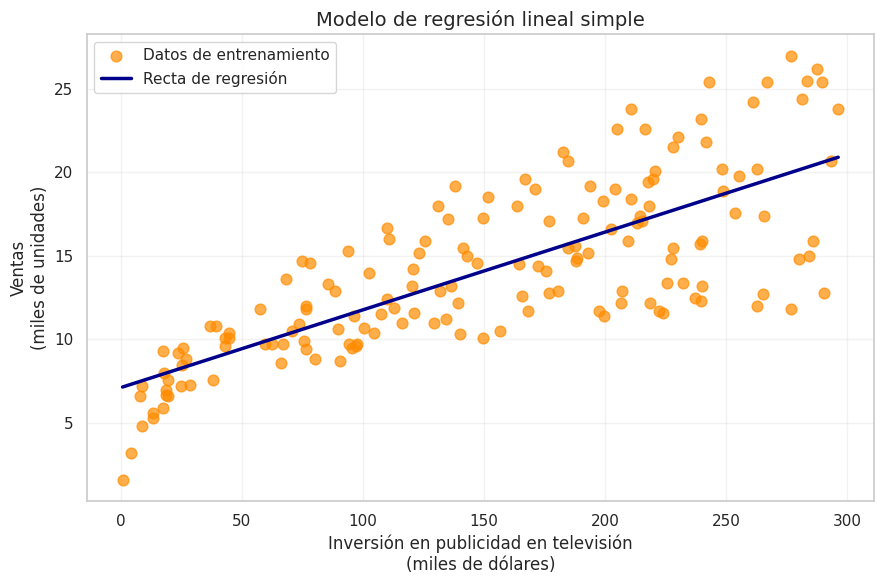

In [12]:
valores_tv = np.linspace(
    X_entrenamiento["TV"].min(),
    X_entrenamiento["TV"].max(),
    200
)
X_linea = pd.DataFrame({
    "TV": valores_tv
})
y_linea = modelo_simple.predict(X_linea)
plt.figure(figsize=(9, 6))
plt.scatter(
    X_entrenamiento["TV"],
    y_entrenamiento,
    color="darkorange",
    alpha=0.70,
    s=60,
    label="Datos de entrenamiento"
)
plt.plot(
    valores_tv,
    y_linea,
    color="darkblue",
    linewidth=2.5,
    label="Recta de regresión"
)
plt.title(
    "Modelo de regresión lineal simple",
    fontsize=14
)
plt.xlabel(
    "Inversión en publicidad en televisión\n(miles de dólares)"
)
plt.ylabel(
    "Ventas\n(miles de unidades)"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Predicciones con los datos de prueba

El modelo se entrenó con 160 observaciones. Ahora utilizaremos las 40
observaciones de prueba para evaluar su capacidad de predicción.

La función `predict()` recibe los valores de inversión en televisión del
conjunto de prueba y calcula las ventas estimadas:
$$
\hat{Y}
=
7.1196+0.0465X
$$
Posteriormente compararemos:

- el valor de inversión en televisión;
- las ventas realmente observadas;
- las ventas estimadas por el modelo;
- el residuo de cada predicción.

El residuo se calcula mediante:

$$
e=Y-\hat{Y}
$$

In [13]:
y_prediccion = modelo_simple.predict(X_prueba)
resultados_prueba = pd.DataFrame({
    "TV": X_prueba["TV"],
    "ventas_reales": y_prueba,
    "ventas_estimadas": y_prediccion
})
resultados_prueba["residuo"] = (
    resultados_prueba["ventas_reales"]
    - resultados_prueba["ventas_estimadas"]
)
resultados_prueba.round(2).head(10)

,TV,ventas_reales,ventas_estimadas,residuo
96,163.3,16.9,14.72,2.18
16,195.4,22.4,16.21,6.19
31,292.9,21.4,20.75,0.65
159,11.7,7.3,7.66,-0.36
129,220.3,24.7,17.37,7.33
116,75.1,12.6,10.61,1.99
70,216.8,22.3,17.21,5.09
171,50.0,8.4,9.45,-1.05
175,222.4,11.5,17.47,-5.97
46,175.1,14.9,15.27,-0.37


## Análisis de las predicciones y los residuos

**Para una inversión en televisión de 220.3, el valor real de las ventas
es 24.7 y el modelo estimó 17.37. ¿Cómo se interpreta el residuo de 7.33?**

**Para una inversión en televisión de 222.4, el residuo es \(-5.97\).
¿Qué indica el signo negativo y cómo se comportó el modelo en esta
observación?**
**¿Todos los residuos presentan la misma magnitud? ¿Qué indica esto sobre
las predicciones del modelo?**

## 13. Métricas de evaluación

Para evaluar el modelo utilizaremos las predicciones realizadas sobre
las 40 observaciones de prueba.

Calcularemos cuatro métricas:

### Coeficiente de determinación

$$
R^2
=
1-
\frac{\sum (Y_i-\hat{Y}_i)^2}
{\sum (Y_i-\bar{Y})^2}
$$

\(R^2\) representa la proporción de la variabilidad de las ventas que el
modelo logra explicar. Un valor más cercano a 1 indica una mayor capacidad
explicativa.

### Error absoluto medio

$$
MAE
=
\frac{1}{n}
\sum_{i=1}^{n}
|Y_i-\hat{Y}_i|
$$

El MAE representa la magnitud promedio de los errores, sin considerar
su signo.

### Error cuadrático medio

$$
MSE
=
\frac{1}{n}
\sum_{i=1}^{n}
(Y_i-\hat{Y}_i)^2
$$

El MSE eleva los errores al cuadrado, por lo que penaliza con mayor
intensidad las predicciones que presentan errores grandes.

### Raíz del error cuadrático medio

$$
RMSE
=
\sqrt{MSE}
$$

El RMSE expresa el error en las mismas unidades de la variable `sales`,
es decir, en miles de unidades vendidas.

Para MAE, MSE y RMSE, valores menores indican predicciones más cercanas
a los valores observados.

In [14]:
r2 = r2_score(
    y_prueba,
    y_prediccion
)
mae = mean_absolute_error(
    y_prueba,
    y_prediccion
)
mse = mean_squared_error(
    y_prueba,
    y_prediccion
)
rmse = np.sqrt(mse)
metricas_modelo_simple = pd.DataFrame({
    "Métrica": [
        "R²",
        "MAE",
        "MSE",
        "RMSE"
    ],
    "Resultado": [
        r2,
        mae,
        mse,
        rmse
    ]
})
metricas_modelo_simple.round(4)

,Métrica,Resultado
0,R²,0.6767
1,MAE,2.4444
2,MSE,10.2047
3,RMSE,3.1945


## Interpretación de las métricas del modelo

**¿Cómo se interpreta el valor \(R^2=0.6767\) en el contexto de las
ventas?**

**¿Cómo se interpreta el valor \(MAE=2.4444\)?**

**El RMSE es mayor que el MAE. ¿Qué indica esta diferencia sobre los
errores del modelo?**


### Interpretación general del modelo simple

El modelo basado únicamente en la inversión en televisión explica el
67.67 % de la variabilidad de las ventas en el conjunto de prueba.

Las predicciones presentan un error absoluto promedio de 2.44 mil
unidades y un RMSE de 3.19 mil unidades. El modelo posee capacidad
predictiva, pero todavía deja una parte relevante de la variabilidad sin
explicar.

Este resultado justifica evaluar posteriormente un modelo de regresión
múltiple que incorpore también la inversión en radio y prensa.

## Comparación entre valores reales y valores estimados

Después de calcular las métricas de evaluación, compararemos gráficamente las ventas observadas en el conjunto de prueba con las ventas estimadas por el modelo.

La línea diagonal representa una **predicción perfecta**, es decir, los puntos en los que el valor estimado coincide exactamente con el valor real.

- Los puntos cercanos a la línea indican predicciones más precisas.
- Los puntos por encima de la línea indican que el modelo sobreestimó las ventas.
- Los puntos por debajo de la línea indican que el modelo subestimó las ventas.

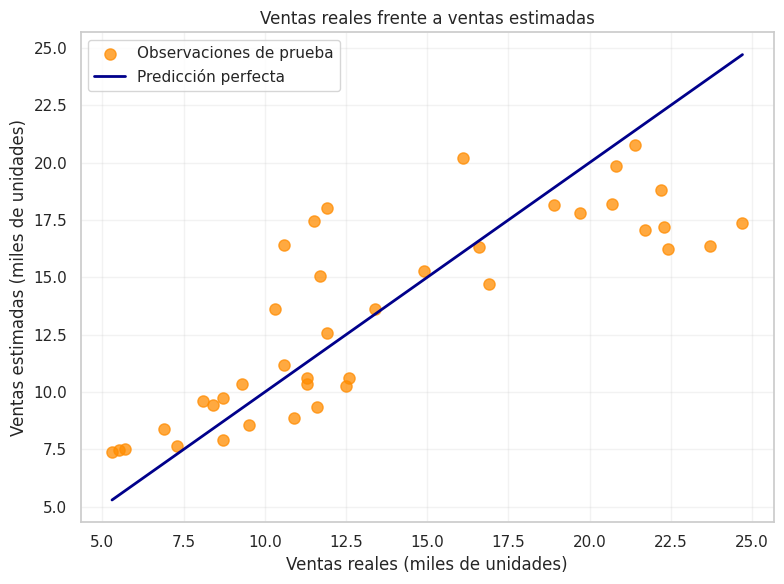

In [15]:
limite_inferior = min(y_prueba.min(), y_prediccion.min())
limite_superior = max(y_prueba.max(), y_prediccion.max())
plt.figure(figsize=(8, 6))

plt.scatter(
    y_prueba,
    y_prediccion,
    color="darkorange",
    s=65,
    alpha=0.75,
    label="Observaciones de prueba"
)
plt.plot(
    [limite_inferior, limite_superior],
    [limite_inferior, limite_superior],
    color="darkblue",
    linewidth=2,
    label="Predicción perfecta"
)
plt.title("Ventas reales frente a ventas estimadas")
plt.xlabel("Ventas reales (miles de unidades)")
plt.ylabel("Ventas estimadas (miles de unidades)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Preguntas de análisis

- ¿Qué representa la línea azul denominada **predicción perfecta**?

- ¿Qué significa que una observación se encuentre cerca de la línea azul?

- En las observaciones con ventas reales superiores a 20 mil unidades, ¿el modelo tiende a sobreestimar o a subestimar las ventas?

- ¿La gráfica indica que todas las predicciones tienen la misma precisión? Justifique su respuesta.

## Análisis gráfico de los residuos

El residuo representa la diferencia entre el valor real y el valor estimado:

$$
e_i = Y_i - \hat{Y}_i
$$

En el siguiente gráfico se representan los residuos frente a las ventas estimadas.

En un modelo lineal adecuado se espera que:

- los residuos se distribuyan alrededor de cero;
- aparezcan valores positivos y negativos;
- no exista una curva ni otro patrón evidente;
- la dispersión sea relativamente similar a lo largo del gráfico.

La línea horizontal en cero representa una predicción sin error.

- Un residuo positivo indica que el modelo subestimó las ventas.
- Un residuo negativo indica que el modelo sobreestimó las ventas.

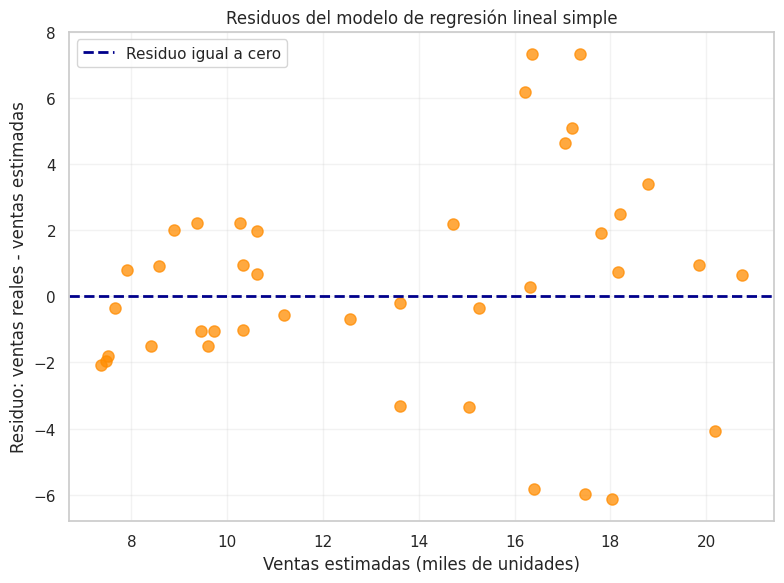

In [16]:
residuos = y_prueba - y_prediccion
plt.figure(figsize=(8, 6))
plt.scatter(
    y_prediccion,
    residuos,
    color="darkorange",
    s=65,
    alpha=0.75
)
plt.axhline(
    y=0,
    color="darkblue",
    linestyle="--",
    linewidth=2,
    label="Residuo igual a cero"
)
plt.title("Residuos del modelo de regresión lineal simple")
plt.xlabel("Ventas estimadas (miles de unidades)")
plt.ylabel("Residuo: ventas reales - ventas estimadas")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Predicción para una nueva inversión en televisión

Una vez entrenado y evaluado el modelo, podemos utilizarlo para estimar las ventas esperadas ante una nueva inversión en publicidad.

La ecuación obtenida fue:
$$
\widehat{\text{sales}}
=
7.1196 + 0.0465(\text{TV})
$$

Realizaremos una predicción para una empresa que invierte **180 mil dólares en publicidad de televisión**.

La predicción puede calcularse de dos formas:

- sustituyendo el valor de `TV` en la ecuación;
- utilizando el método `predict()` del modelo.

Ambos procedimientos deben producir resultados aproximadamente iguales.

In [17]:
nueva_inversion = 180
prediccion_manual = (
    modelo_simple.intercept_
    + modelo_simple.coef_[0] * nueva_inversion
)
nuevo_dato = pd.DataFrame({
    "TV": [nueva_inversion]
})
prediccion_modelo = modelo_simple.predict(nuevo_dato)[0]
print(f"Inversión en televisión: {nueva_inversion} mil dólares")
print(f"Predicción mediante la ecuación: {prediccion_manual:.4f} mil unidades")
print(f"Predicción mediante predict(): {prediccion_modelo:.4f} mil unidades")

Inversión en televisión: 180 mil dólares
Predicción mediante la ecuación: 15.4950 mil unidades
Predicción mediante predict(): 15.4950 mil unidades


### Preguntas de análisis

- ¿Cuál es la cantidad de ventas estimada para una inversión de 180 mil dólares en televisión?

- ¿Por qué la predicción manual y la obtenida mediante `predict()` producen el mismo resultado?

- ¿El resultado significa que la empresa venderá exactamente 15 495 unidades? Justifique su respuesta.

### Preguntas de análisis

- ¿Cuál es la cantidad de ventas estimada para una inversión de 180 mil dólares en televisión?

- ¿Por qué la predicción manual y la obtenida mediante `predict()` producen el mismo resultado?

- ¿El resultado significa que la empresa venderá exactamente 15 495 unidades? Justifique su respuesta.